Tugas 1A Pemrograman Bahasa Alami - Metta Anjali Putri - 5026231205

1. Install & Import Library

In [ ]:
!pip install google-play-scraper -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import time
import warnings

from google_play_scraper import reviews, Sort

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

2. Scraping Google Play Reviews — BookCabin

In [ ]:
print("🔍 Scraping semua review BookCabin...")

all_reviews = []
sort_methods = [Sort.NEWEST, Sort.MOST_RELEVANT, Sort.RATING]

for sort_method in sort_methods:
    print(f"\n→ Sorting: {sort_method}")
    continuation_token = None

    while True:
        result, continuation_token = reviews(
            'com.kabinkitatop.bookcabin',
            lang='id',
            country='id',
            sort=sort_method,
            count=200,
            continuation_token=continuation_token
        )
        if not result:
            break
        all_reviews.extend(result)
        print(f"  Total sementara: {len(all_reviews)}")
        if continuation_token is None:
            break
        time.sleep(1)

# Convert ke DataFrame — simpan kolom 'at' untuk analisis waktu
df_raw = pd.DataFrame(all_reviews)
df = df_raw[['content', 'score', 'at']].copy()
df = df.dropna(subset=['content'])
df = df.drop_duplicates(subset='content')
df['score'] = df['score'].astype(int)
df['at']    = pd.to_datetime(df['at'])

df.to_csv('bookcabin_all_reviews.csv', index=False, encoding='utf-8-sig')
print("Tersimpan: bookcabin_all_reviews.csv")
df.head()

🔍 Scraping semua review BookCabin...

→ Sorting: Sort.NEWEST
  Total sementara: 200
  Total sementara: 400
  Total sementara: 600
  Total sementara: 800
  Total sementara: 1000
  Total sementara: 1200
  Total sementara: 1400
  Total sementara: 1600
  Total sementara: 1800
  Total sementara: 2000
  Total sementara: 2200
  Total sementara: 2400
  Total sementara: 2600
  Total sementara: 2800
  Total sementara: 3000
  Total sementara: 3200
  Total sementara: 3400
  Total sementara: 3600
  Total sementara: 3800
  Total sementara: 4000
  Total sementara: 4071

→ Sorting: Sort.MOST_RELEVANT
  Total sementara: 4271
  Total sementara: 4471
  Total sementara: 4671
  Total sementara: 4871
  Total sementara: 5071
  Total sementara: 5271
  Total sementara: 5471
  Total sementara: 5671
  Total sementara: 5871
  Total sementara: 6071
  Total sementara: 6271
  Total sementara: 6471
  Total sementara: 6671
  Total sementara: 6871
  Total sementara: 7071
  Total sementara: 7271
  Total sementara: 7471


,content,score,at
0,lebih murah,5,2026-03-30 15:13:05
1,aplikasi terpercaya dan termurah,5,2026-03-30 14:46:40
2,cepat,5,2026-03-30 13:30:41
3,Apk ribeeeeeeeeet,1,2026-03-30 12:54:59
4,sangat bermanfaat dan mudah bertransaksi,5,2026-03-30 07:56:20


3. Exploratory Data Analysis (EDA)

In [ ]:
# Info dasar dataset
print("=" * 50)
print(f"Total review   : {len(df)}")
print(f"Rentang tanggal: {df['at'].min().date()} s/d {df['at'].max().date()}")
print(f"\nDistribusi rating:")
rating_dist = df['score'].value_counts().sort_index()
for star, count in rating_dist.items():
    bar = '█' * int(count / rating_dist.max() * 30)
    print(f"  {star}★  {bar}  {count} ({count/len(df)*100:.1f}%)")

Total review   : 3333
Rentang tanggal: 2023-09-22 s/d 2026-03-30

Distribusi rating:
  1★  ████████  678 (20.3%)
  2★  █  90 (2.7%)
  3★    76 (2.3%)
  4★  █  129 (3.9%)
  5★  ██████████████████████████████  2360 (70.8%)


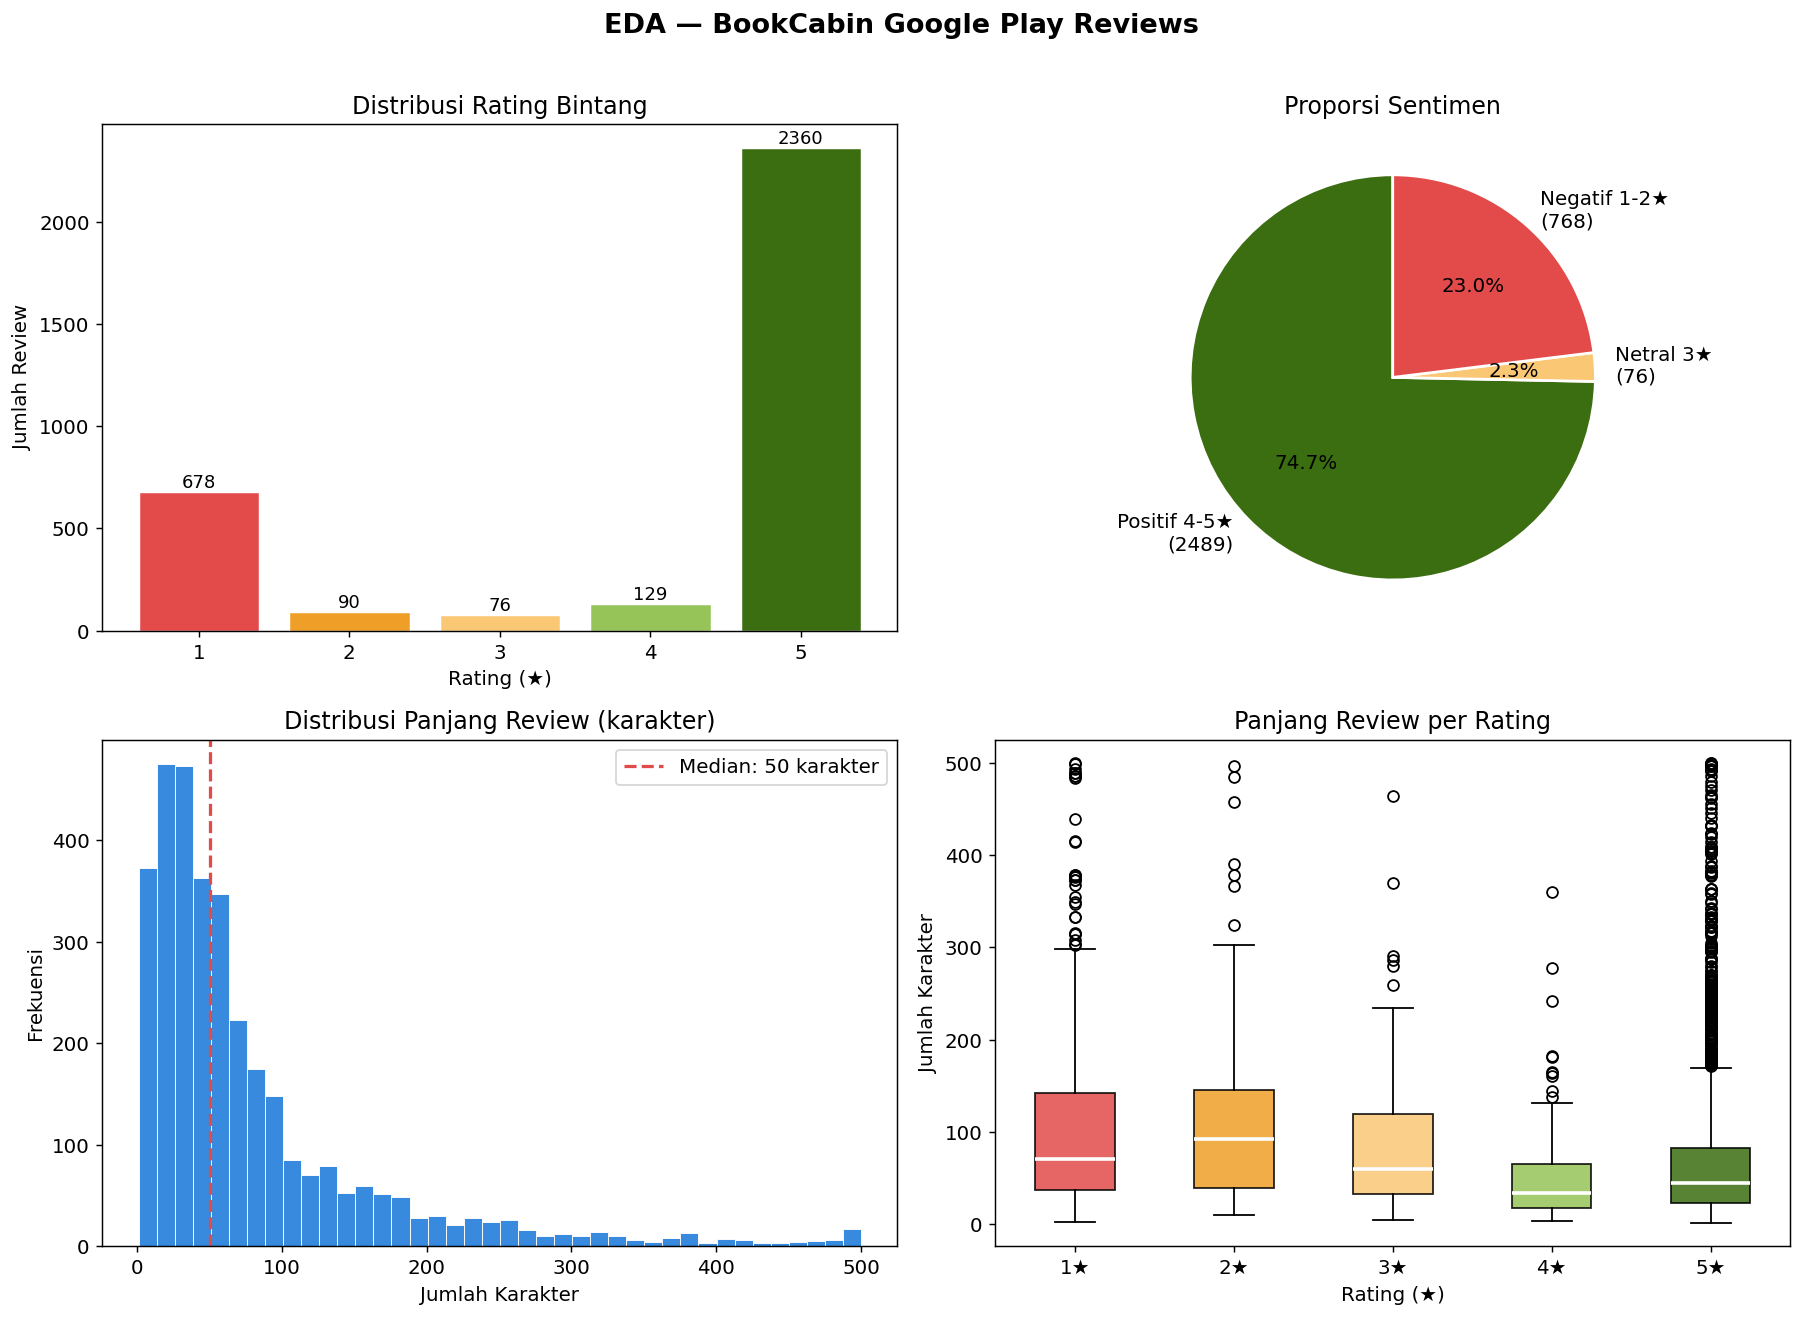

In [ ]:
# Visualisasi EDA — 2x2 grid
df['review_length'] = df['content'].str.len()
df['word_count']    = df['content'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — BookCabin Google Play Reviews', fontsize=15, fontweight='bold', y=1.01)

COLORS = ['#E24B4A', '#EF9F27', '#FAC775', '#97C459', '#3B6D11']

# (1) Distribusi rating
rating_counts = df['score'].value_counts().sort_index()
axes[0,0].bar(rating_counts.index, rating_counts.values, color=COLORS, edgecolor='white', linewidth=0.8)
axes[0,0].set_title('Distribusi Rating Bintang')
axes[0,0].set_xlabel('Rating (★)')
axes[0,0].set_ylabel('Jumlah Review')
for idx, val in zip(rating_counts.index, rating_counts.values):
    axes[0,0].text(idx, val + max(rating_counts)*0.01, str(val), ha='center', fontsize=10)

# (2) Pie sentimen
pos = (df['score'] >= 4).sum()
neu = (df['score'] == 3).sum()
neg = (df['score'] <= 2).sum()
axes[0,1].pie(
    [pos, neu, neg],
    labels=[f'Positif 4-5★\n({pos})', f'Netral 3★\n({neu})', f'Negatif 1-2★\n({neg})'],
    autopct='%1.1f%%',
    colors=['#3B6D11', '#FAC775', '#E24B4A'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0,1].set_title('Proporsi Sentimen')

# (3) Histogram panjang review
axes[1,0].hist(df['review_length'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[1,0].axvline(df['review_length'].median(), color='#E24B4A', linestyle='--', linewidth=1.8,
                  label=f"Median: {int(df['review_length'].median())} karakter")
axes[1,0].set_title('Distribusi Panjang Review (karakter)')
axes[1,0].set_xlabel('Jumlah Karakter')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend()

# (4) Boxplot panjang review per rating
data_by_rating = [df[df['score'] == s]['review_length'].values for s in range(1, 6)]
bp = axes[1,1].boxplot(data_by_rating, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1,1].set_title('Panjang Review per Rating')
axes[1,1].set_xlabel('Rating (★)')
axes[1,1].set_ylabel('Jumlah Karakter')
axes[1,1].set_xticklabels(['1★','2★','3★','4★','5★'])

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Statistik deskriptif
print("Statistik panjang review:")
print(df['review_length'].describe().round(1))

print("\nRata-rata panjang & jumlah kata per rating:")
print(
    df.groupby('score')[['review_length', 'word_count']]
    .mean().round(1)
    .rename(columns={'review_length': 'avg_karakter', 'word_count': 'avg_kata'})
)

Statistik panjang review:
count    3333.0
mean       78.5
std        85.6
min         1.0
25%        25.0
50%        50.0
75%        94.0
max       500.0
Name: review_length, dtype: float64

Rata-rata panjang & jumlah kata per rating:
       avg_karakter  avg_kata
score                        
1             101.5      16.3
2             120.1      19.1
3              93.2      14.4
4              52.0       8.1
5              71.3      10.7


4. N= Reviews per Year

In [ ]:
# Ekstrak fitur waktu
df['year']    = df['at'].dt.year
df['month']   = df['at'].dt.to_period('M')
df['sentimen'] = df['score'].apply(lambda x: 'Positif' if x >= 4 else ('Negatif' if x <= 2 else 'Netral'))

print("N= Review per Tahun:")
year_counts = df['year'].value_counts().sort_index()
for yr, cnt in year_counts.items():
    print(f"  {yr}: {cnt} review")

print("\nRata-rata rating per tahun:")
print(df.groupby('year')['score'].mean().round(2))

N= Review per Tahun:
  2023: 277 review
  2024: 1123 review
  2025: 1568 review
  2026: 365 review

Rata-rata rating per tahun:
year
2023    1.77
2024    3.97
2025    4.45
2026    4.04
Name: score, dtype: float64


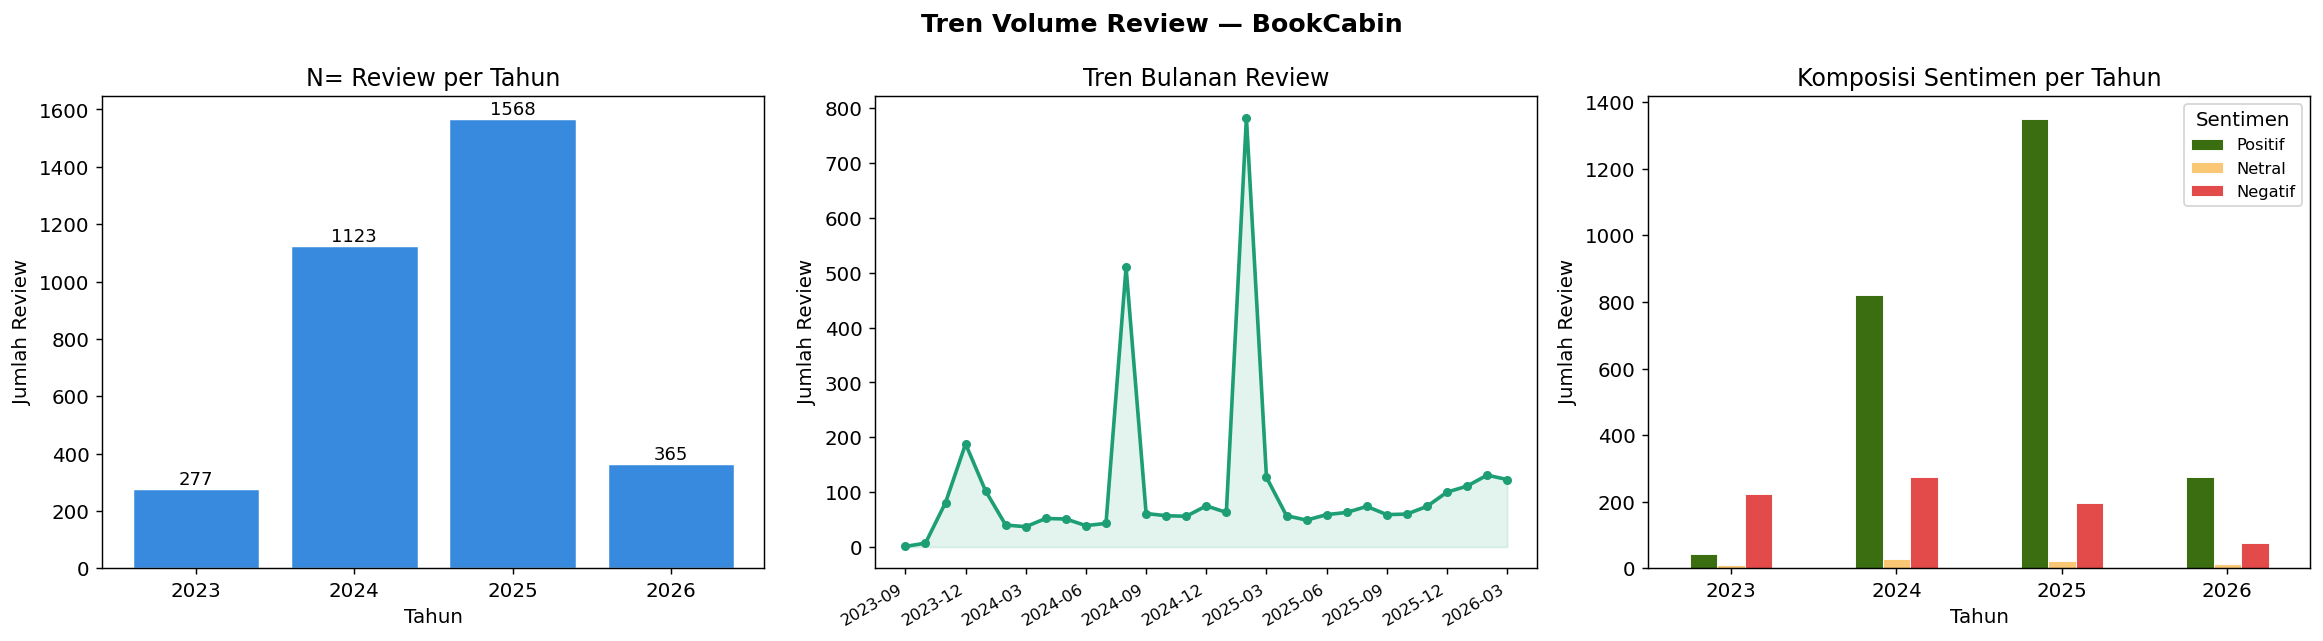

In [ ]:
# Visualisasi tren waktu — 1x3 grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Tren Volume Review — BookCabin', fontsize=14, fontweight='bold')

# (1) Bar N= per tahun
axes[0].bar(year_counts.index.astype(str), year_counts.values,
            color='#378ADD', edgecolor='white', linewidth=0.8)
axes[0].set_title('N= Review per Tahun')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Review')
for i, (yr, cnt) in enumerate(year_counts.items()):
    axes[0].text(i, cnt + max(year_counts)*0.01, str(cnt), ha='center', fontsize=10)

# (2) Line tren bulanan
monthly = df.groupby('month').size().reset_index(name='count')
monthly['idx'] = range(len(monthly))
axes[1].plot(monthly['idx'], monthly['count'], color='#1D9E75', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(monthly['idx'], monthly['count'], alpha=0.12, color='#1D9E75')
axes[1].set_title('Tren Bulanan Review')
axes[1].set_ylabel('Jumlah Review')
step = max(1, len(monthly)//8)
axes[1].set_xticks(monthly['idx'][::step])
axes[1].set_xticklabels(monthly['month'].astype(str)[::step], rotation=30, ha='right', fontsize=9)

# (3) Stacked bar sentimen per tahun
pivot = df.groupby(['year','sentimen']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['Positif','Netral','Negatif'], fill_value=0)
pivot.plot(kind='bar', ax=axes[2], color=['#3B6D11','#FAC775','#E24B4A'],
           edgecolor='white', linewidth=0.5)
axes[2].set_title('Komposisi Sentimen per Tahun')
axes[2].set_xlabel('Tahun')
axes[2].set_ylabel('Jumlah Review')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Sentimen', fontsize=9)

plt.tight_layout()
plt.savefig('reviews_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

5. BoW - Bag of Words

In [ ]:
# Preprocessing & tokenisasi
STOPWORDS_ID = set([
    'yang','dan','di','ke','dari','ini','itu','dengan','untuk','ada',
    'tidak','bisa','saya','aku','kita','kamu','ya','ga','gak','nggak',
    'tapi','juga','sudah','atau','jadi','seperti','lebih','sangat',
    'sekali','aja','sih','dong','deh','banget','nya','pun','lagi',
    'kalau','karena','bila','mau','buat','the','a','an','is','in',
    'of','to','app','apps','aplikasi','lah','wah','ah','oh','nih',
    'tuh','pas','udah','udh','sama','bagi','maka','agar','saat','pada'
])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return [w for w in clean_text(text).split()
            if w not in STOPWORDS_ID and len(w) > 2]

# Ambil 50 review positif dan 50 review negatif
df_pos = df[df['score'] >= 4].head(50).copy()
df_neg = df[df['score'] <= 2].head(50).copy()

tokens_pos = [tok for text in df_pos['content'] for tok in tokenize(text)]
tokens_neg = [tok for text in df_neg['content'] for tok in tokenize(text)]

freq_pos = Counter(tokens_pos)
freq_neg = Counter(tokens_neg)

print(f"Token positif : {len(tokens_pos)} total | {len(freq_pos)} unik")
print(f"Token negatif : {len(tokens_neg)} total | {len(freq_neg)} unik")

Token positif : 184 total | 120 unik
Token negatif : 788 total | 462 unik


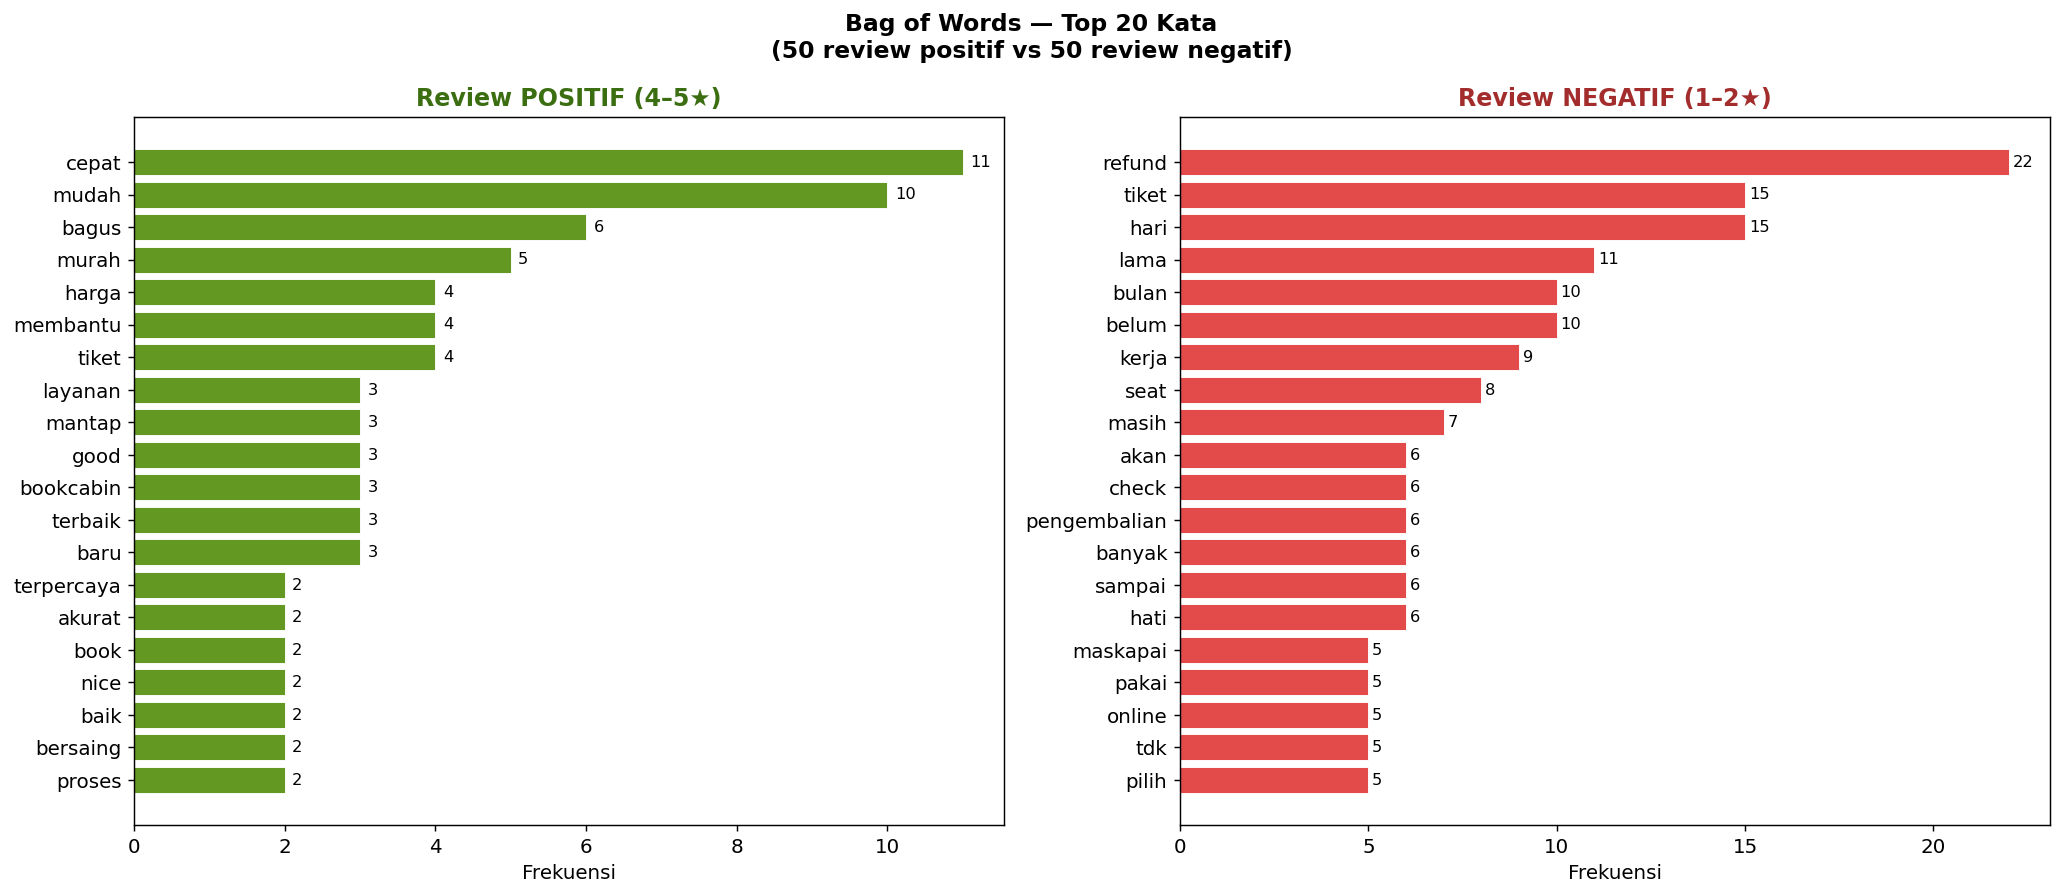

In [ ]:
# Visualisasi BoW — Top 20 kata
TOP_N = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Bag of Words — Top {TOP_N} Kata\n(50 review positif vs 50 review negatif)',
             fontsize=13, fontweight='bold')

words_p, counts_p = zip(*freq_pos.most_common(TOP_N))
axes[0].barh(list(reversed(words_p)), list(reversed(counts_p)),
             color='#639922', edgecolor='white', linewidth=0.5)
axes[0].set_title('Review POSITIF (4–5★)', color='#3B6D11', fontweight='bold')
axes[0].set_xlabel('Frekuensi')
for i, v in enumerate(reversed(counts_p)):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=9)

words_n, counts_n = zip(*freq_neg.most_common(TOP_N))
axes[1].barh(list(reversed(words_n)), list(reversed(counts_n)),
             color='#E24B4A', edgecolor='white', linewidth=0.5)
axes[1].set_title('Review NEGATIF (1–2★)', color='#A32D2D', fontweight='bold')
axes[1].set_xlabel('Frekuensi')
for i, v in enumerate(reversed(counts_n)):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('bow_positif_negatif.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tabel perbandingan top kata
df_bow = pd.DataFrame({
    'kata_positif' : [w for w, _ in freq_pos.most_common(TOP_N)],
    'freq_pos'     : [c for _, c in freq_pos.most_common(TOP_N)],
    'kata_negatif' : [w for w, _ in freq_neg.most_common(TOP_N)],
    'freq_neg'     : [c for _, c in freq_neg.most_common(TOP_N)],
})
print(df_bow.to_string(index=False))

kata_positif  freq_pos kata_negatif  freq_neg
       cepat        11       refund        22
       mudah        10        tiket        15
       bagus         6         hari        15
       murah         5         lama        11
       harga         4        bulan        10
    membantu         4        belum        10
       tiket         4        kerja         9
     layanan         3         seat         8
      mantap         3        masih         7
        good         3         akan         6
   bookcabin         3        check         6
     terbaik         3 pengembalian         6
        baru         3       banyak         6
  terpercaya         2       sampai         6
      akurat         2         hati         6
        book         2     maskapai         5
        nice         2        pakai         5
        baik         2       online         5
    bersaing         2          tdk         5
      proses         2        pilih         5


6. Studi Kasus Insights Positif & Negatif

In [ ]:
# Definisi pola regex per topik
PATTERNS = {
    '👍 Mudah digunakan'   : r'\b(mudah|gampang|praktis|intuitif|simpel)\b',
    '👍 Konten lengkap'    : r'\b(lengkap|banyak|koleksi|pilihan|beragam|variatif)\b',
    '👍 Rekomendasi'       : r'\b(rekomen|recommend|mantap|keren|luar biasa)\b',
    '👍 Harga terjangkau'  : r'\b(murah|terjangkau|worth|harga|berlangganan)\b',
    '👎 Bug / crash'       : r'\b(crash|error|bug|force.?close|hang|lemot|lambat)\b',
    '👎 Tidak bisa buka'   : r'\b(tidak bisa|gabisa|gagal|loading|blank|putih|stuck)\b',
    '👎 Konten kurang'     : r'\b(kurang|sedikit|jarang|update|diperbarui|terbatas)\b',
    '👎 Iklan mengganggu'  : r'\b(iklan|ads|reklame|pop.?up)\b',
}

results = []
for label, pattern in PATTERNS.items():
    match_pos = df_pos['content'].str.contains(pattern, case=False, regex=True).sum()
    match_neg = df_neg['content'].str.contains(pattern, case=False, regex=True).sum()
    results.append({'Topik': label, 'Review Positif': match_pos, 'Review Negatif': match_neg})

df_regex = pd.DataFrame(results)
print(df_regex.to_string(index=False))



             Topik  Review Positif  Review Negatif
 👍 Mudah digunakan               9               0
  👍 Konten lengkap               1               5
     👍 Rekomendasi               4               1
👍 Harga terjangkau              10               1
     👎 Bug / crash               0               4
 👎 Tidak bisa buka               0               4
   👎 Konten kurang               0               2
👎 Iklan mengganggu               0               0


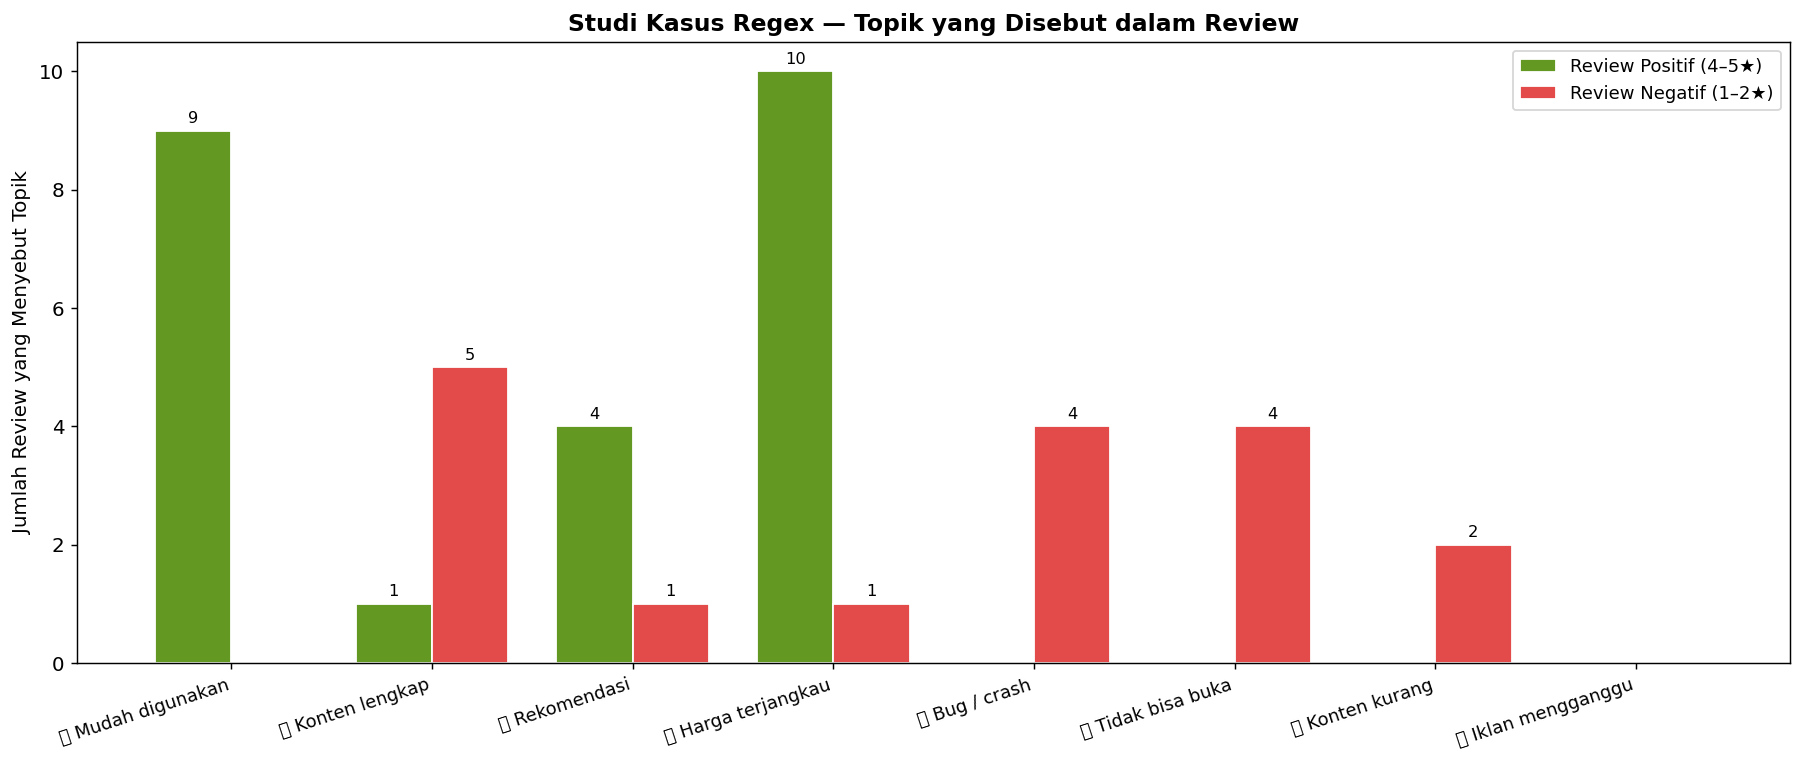

In [ ]:
# Visualisasi grouped bar regex
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(df_regex))
width = 0.38

bars1 = ax.bar(x - width/2, df_regex['Review Positif'], width,
               label='Review Positif (4–5★)', color='#639922', edgecolor='white')
bars2 = ax.bar(x + width/2, df_regex['Review Negatif'], width,
               label='Review Negatif (1–2★)', color='#E24B4A', edgecolor='white')

ax.set_title('Studi Kasus Regex — Topik yang Disebut dalam Review',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_regex['Topik'], rotation=18, ha='right', fontsize=10)
ax.set_ylabel('Jumlah Review yang Menyebut Topik')
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.08,
                int(h), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('regex_insights.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Contoh kutipan review per topik
EXAMPLE_TOPICS = {
    'Bug / crash (negatif)'      : (df_neg, r'\b(crash|error|bug|force.?close|hang|lemot|lambat)\b'),
    'Konten lengkap (positif)'   : (df_pos, r'\b(lengkap|banyak|koleksi|pilihan|beragam)\b'),
    'Iklan mengganggu (negatif)' : (df_neg, r'\b(iklan|ads|reklame|pop.?up)\b'),
    'Mudah digunakan (positif)'  : (df_pos, r'\b(mudah|gampang|praktis|intuitif)\b'),
}

for topic, (data, pattern) in EXAMPLE_TOPICS.items():
    mask   = data['content'].str.contains(pattern, case=False, regex=True)
    subset = data[mask].head(2)
    print(f"\n{'─'*60}")
    print(f"📌 {topic} ({mask.sum()} review cocok)")
    print(f"{'─'*60}")
    if len(subset) == 0:
        print("  (tidak ada yang cocok dalam sampel 50)")
    for _, row in subset.iterrows():
        print(f"  [{row['score']}★] {str(row['content'])[:250]}")


────────────────────────────────────────────────────────────
📌 Bug / crash (negatif) (4 review cocok)
────────────────────────────────────────────────────────────
  [1★] perbaiki lagi, karena server sering error
  [2★] pengembalian Refund sangat lama bisa lebih 7 hari kerja, beda dengan aplikasi traveloka ketika refund cepat dan uangnya bisa segera digunakan, aplikasi ini lambat ketika ingin pesan tiket lain tapi uangnya belum dikembalikan

────────────────────────────────────────────────────────────
📌 Konten lengkap (positif) (1 review cocok)
────────────────────────────────────────────────────────────
  [5★] baru dpt aplikasi yg lengkap dg cekin online secara mudah...👍👍

────────────────────────────────────────────────────────────
📌 Iklan mengganggu (negatif) (0 review cocok)
────────────────────────────────────────────────────────────
  (tidak ada yang cocok dalam sampel 50)

────────────────────────────────────────────────────────────
📌 Mudah digunakan (positif) (9 review cocok)
─

7. Summary

In [ ]:
pos_pct    = (df['score'] >= 4).mean() * 100
neg_pct    = (df['score'] <= 2).mean() * 100
neu_pct    = (df['score'] == 3).mean() * 100
avg_rating = df['score'].mean()

print("=" * 55)
print("      RINGKASAN ANALISIS — BOOKCABIN REVIEWS")
print("=" * 55)
print(f"  Total review       : {len(df)}")
print(f"  Rentang data       : {df['at'].min().year} – {df['at'].max().year}")
print(f"  Rata-rata rating   : {avg_rating:.2f} ★")
print(f"  Positif (4-5★)     : {pos_pct:.1f}%")
print(f"  Netral  (3★)       : {neu_pct:.1f}%")
print(f"  Negatif (1-2★)     : {neg_pct:.1f}%")
print()
print("  Top 5 kata — Review POSITIF:")
for w, c in freq_pos.most_common(5):
    print(f"    → '{w}' ({c}x)")
print()
print("  Top 5 kata — Review NEGATIF:")
for w, c in freq_neg.most_common(5):
    print(f"    → '{w}' ({c}x)")
print("=" * 55)

      RINGKASAN ANALISIS — BOOKCABIN REVIEWS
  Total review       : 3333
  Rentang data       : 2023 – 2026
  Rata-rata rating   : 4.02 ★
  Positif (4-5★)     : 74.7%
  Netral  (3★)       : 2.3%
  Negatif (1-2★)     : 23.0%

  Top 5 kata — Review POSITIF:
    → 'cepat' (11x)
    → 'mudah' (10x)
    → 'bagus' (6x)
    → 'murah' (5x)
    → 'harga' (4x)

  Top 5 kata — Review NEGATIF:
    → 'refund' (22x)
    → 'tiket' (15x)
    → 'hari' (15x)
    → 'lama' (11x)
    → 'bulan' (10x)
